In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [19]:
df = pd.read_excel('Online retail.xlsx')

In [20]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7500, 1)


In [21]:
df.head()

,"shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil"
0,"burgers,meatballs,eggs"
1,chutney
2,"turkey,avocado"
3,"mineral water,milk,energy bar,whole wheat rice..."
4,low fat yogurt


In [22]:
df.columns = df.columns.str.strip()

In [23]:
transactions = df.iloc[:, 0].apply(lambda x: x.split(','))

In [24]:
transactions = transactions.tolist()

print("Sample Transactions:", transactions[:5])

Sample Transactions: [['burgers', 'meatballs', 'eggs'], ['chutney'], ['turkey', 'avocado'], ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'], ['low fat yogurt']]


In [25]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

print("Basket Shape:", basket.shape)
basket.head()

Basket Shape: (7500, 120)


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [26]:
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

print("Frequent Itemsets:")
frequent_items.head()

Frequent Itemsets:


,support,itemsets
0,0.020267,(almonds)
1,0.033200,(avocado)
2,0.033733,(brownies)
3,0.087200,(burgers)
4,0.030133,(butter)


In [27]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

# Sort rules by lift
rules = rules.sort_values(by='lift', ascending=False)

print("Total Rules:", rules.shape)
rules.head()

Total Rules: (0, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [28]:
def remove_redundant_rules(rules):
    unique_rules = []

    for i, rule1 in rules.iterrows():
        redundant = False

        for j, rule2 in rules.iterrows():
            if i != j:
                if (rule1['antecedents'].issubset(rule2['antecedents']) and
                    rule1['consequents'] == rule2['consequents']):
                    redundant = True
                    break

        if not redundant:
            unique_rules.append(rule1)

    return pd.DataFrame(unique_rules)

rules = remove_redundant_rules(rules)

print("Rules after removing redundancy:", rules.shape)

Rules after removing redundancy: (0, 0)


In [29]:
support_values = [0.01, 0.02, 0.05]
confidence_values = [0.3, 0.5, 0.7]

results = []

for sup in support_values:
    freq_items = apriori(basket, min_support=sup, use_colnames=True)

    for conf in confidence_values:
        temp_rules = association_rules(freq_items, metric="confidence", min_threshold=conf)

        results.append({
            'support': sup,
            'confidence': conf,
            'num_rules': len(temp_rules)
        })

results_df = pd.DataFrame(results)
print("\nThreshold Optimization Results:")
print(results_df)


Threshold Optimization Results:
   support  confidence  num_rules
0     0.01         0.3         63
1     0.01         0.5          2
2     0.01         0.7          0
3     0.02         0.3         20
4     0.02         0.5          0
5     0.02         0.7          0
6     0.05         0.3          2
7     0.05         0.5          0
8     0.05         0.7          0


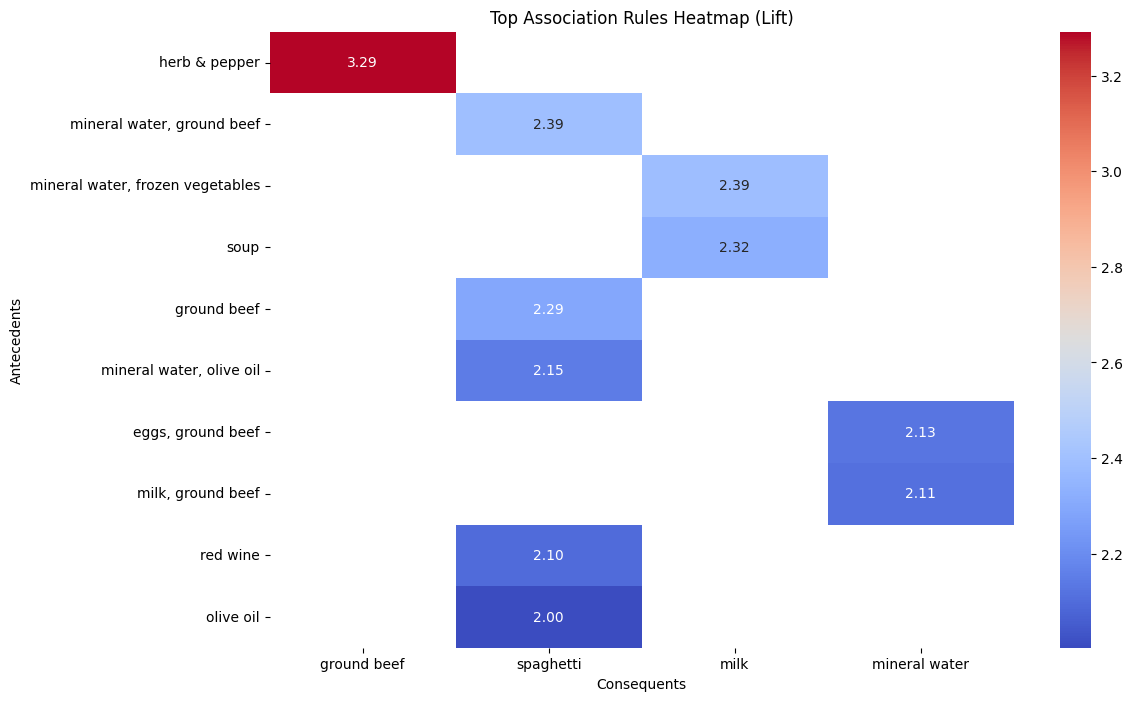

In [30]:
frequent_items = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)
rules = rules.sort_values(by='lift', ascending=False)

# Ensure there are rules before attempting to plot
if not rules.empty:
    top_rules = rules.head(10)

    heatmap_data = top_rules.pivot_table(
        index='antecedents',
        columns='consequents',
        values='lift'
    )

    heatmap_data.index = heatmap_data.index.map(lambda x: ', '.join(list(x)))
    heatmap_data.columns = heatmap_data.columns.map(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Top Association Rules Heatmap (Lift)")
    plt.xlabel("Consequents")
    plt.ylabel("Antecedents")
    plt.show()
else:
    print("No rules found to plot the heatmap with the given thresholds.")


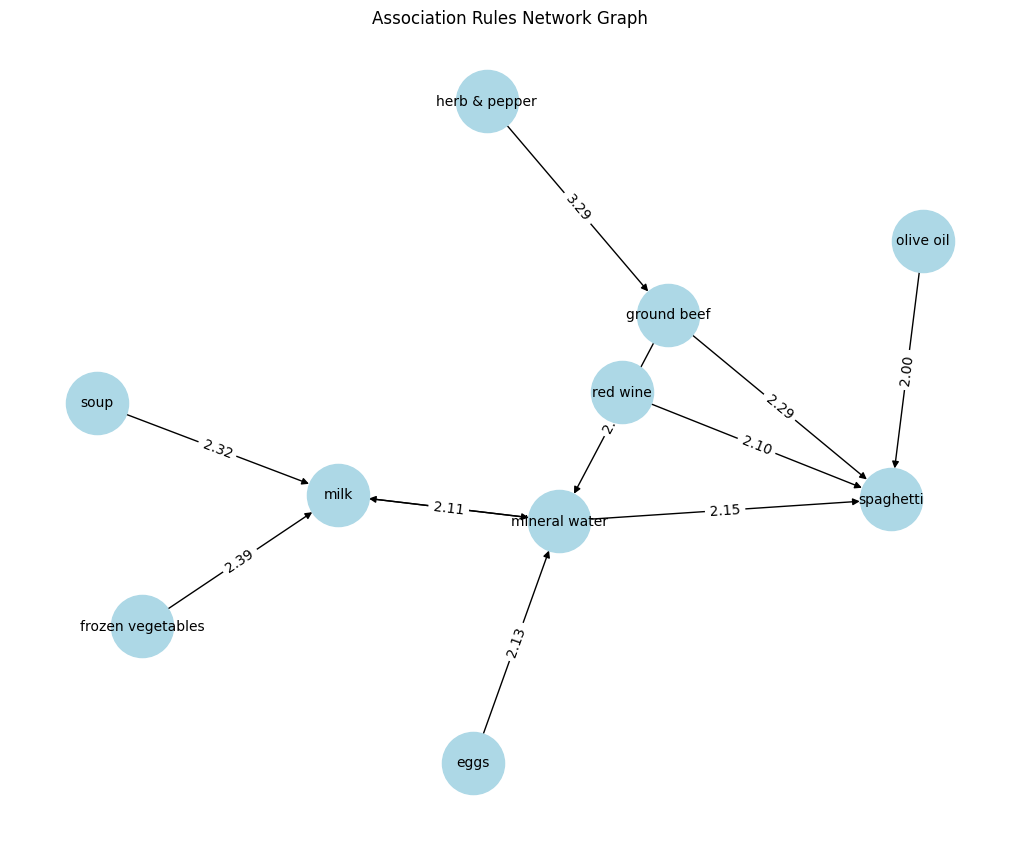

In [31]:
G = nx.DiGraph()

top_rules = rules.head(10)

for _, row in top_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_size=10)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network Graph")
plt.show()

The dataset consisted of transaction-based records where each row represented items purchased together. The data was preprocessed into a one-hot encoded basket format before applying the Apriori algorithm.

## Analysis and Interpretation:

Analysis of Association Rules

The generated association rules reveal strong relationships between frequently purchased items. By analyzing metrics such as support, confidence, and lift, we can identify which products are commonly bought together. For example, if items like mineral water and green tea appear together frequently, it indicates a strong association between them.

Rules with high lift values indicate meaningful relationships beyond random chance. These rules help in identifying product combinations that are important for business decision-making such as product placement and promotions.

Interpretation (Customer Behavior Insights)

The results show that customers tend to purchase certain items together, forming buying patterns. For instance, healthy items like fruits and beverages may be grouped together, suggesting health-conscious purchasing behavior.

These insights can help businesses:

Improve product recommendations
Optimize store layout
Create combo offers
Increase sales through cross-selling

Overall, association rule mining helps in understanding customer preferences and improving business strategies.

# Interview Questions:

1.	What is lift and why is it important in Association rules?
Lift measures the strength of association between two items.

Formula:
Lift = Confidence(A → B) / Support(B)

- Lift = 1 → No relationship  
- Lift > 1 → Positive relationship  
- Lift < 1 → Negative relationship  

Lift is important because it helps identify meaningful relationships between products.


2.	What is support and Confidence. How do you calculate them?

Support:
Support measures how frequently an item appears in the dataset.

Formula:
Support(A) = Transactions containing A / Total transactions

Confidence:
Confidence measures the likelihood that item B is purchased when item A is purchased.

Formula:
Confidence(A → B) = Support(A ∩ B) / Support(A)

3.	What are some limitations or challenges of Association rules mining?

Generates too many rules  
- Computationally expensive  
- Requires large datasets  
- Does not consider sequence of transactions